# Habitia — Modelo de datos: vivienda en Madrid 2018

Construcción del dataset base para el EDA y el modelo predictivo de precios.

**Fuentes**
- `idealista18` — anuncios de venta 2018 ([paezha/idealista18](https://github.com/paezha/idealista18)).
  Rey-Blanco et al. (2024), *EPB: Urban Analytics and City Science*.
- Alquiler por sección censal — Ayuntamiento de Madrid.
- Seccionado censal — INE.

**Salida:** un registro por anuncio, con llave `codigo_censal` para enriquecer
con fuentes externas (renta, seguridad, ambiental).

---

## Cambios respecto a la versión anterior

Tres correcciones metodológicas, documentadas en su sección correspondiente:

| # | Problema | Sección |
|---|---|---|
| 1 | `LOCATIONCODE` de idealista **no es** una sección censal del INE | 4 |
| 2 | Imputación KNN con `PRICE` como predictor → *leakage* | 7 |
| 3 | `alquiler_calculado` derivado de `PRICE` → *leakage* total | 8 |


## 1. Configuración

In [1]:
import os
import urllib.request
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from shapely.geometry import shape

warnings.filterwarnings("ignore", category=UserWarning)

DATA = Path("data")
DATA.mkdir(exist_ok=True)

CRS_GEO = "EPSG:4326"      # WGS84 lon/lat — el CRS nativo de idealista18
CRS_UTM = 25830            # ETRS89 / UTM 30N — métrico, para distancias y áreas

pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid")

## 2. Carga de `idealista18`

El paquete se distribuye solo para R. `rdata` lo lee, pero las columnas de
geometría (`sf`) llegan como listas anidadas y hay que reconstruirlas.

In [2]:
import rdata

ARCHIVOS = ["Madrid_Sale.rda", "Madrid_Polygons.rda", "Madrid_POIS.rda"]
URL_BASE = "https://raw.githubusercontent.com/paezha/idealista18/master/data"


def descargar():
    """Descarga los .rda que falten en ./data."""
    for nombre in ARCHIVOS:
        destino = DATA / nombre
        if not destino.exists():
            urllib.request.urlretrieve(f"{URL_BASE}/{nombre}", destino)
            print(f"descargado {nombre}")


def leer_rda(nombre, encoding=None):
    """Parsea un .rda y devuelve el primer objeto que contiene."""
    parsed = rdata.parser.parse_file(DATA / nombre)
    convertido = rdata.conversion.convert(parsed, default_encoding=encoding)
    return next(iter(convertido.values()))


descargar()
madrid_sale = leer_rda("Madrid_Sale.rda")
madrid_polygons = leer_rda("Madrid_Polygons.rda", encoding="utf8")

print(f"Anuncios:  {madrid_sale.shape}")
print(f"Polígonos: {madrid_polygons.shape}")

Anuncios:  (94815, 42)
Polígonos: (135, 4)


## 3. Reconstrucción de geometrías

Los puntos llegan como `[lon, lat]` y los polígonos como listas anidadas en
formato GeoJSON. Los puntos del fondo son `numpy.ndarray`, no listas — hay que
contemplarlo al detectar la profundidad de anidamiento.

In [3]:
def a_geometria(coords):
    """Lista anidada GeoJSON -> geometría shapely. Idempotente."""
    if hasattr(coords, "geom_type"):          # ya convertida
        return coords

    def profundidad(x):
        es_secuencia = isinstance(x, (list, tuple, np.ndarray))
        return 1 + profundidad(x[0]) if es_secuencia and len(x) else 0

    tipo = "MultiPolygon" if profundidad(coords) == 4 else "Polygon"
    return shape({"type": tipo, "coordinates": coords})


# --- Polígonos (zonas de idealista) ---
madrid_polygons["geometry"] = madrid_polygons["geometry"].apply(a_geometria)
zonas_gdf = gpd.GeoDataFrame(madrid_polygons, geometry="geometry", crs=CRS_GEO)

# --- Puntos (anuncios) ---
coords = np.stack(madrid_sale.geometry.to_numpy())
sale_gdf = gpd.GeoDataFrame(
    madrid_sale.drop(columns="geometry"),
    geometry=gpd.points_from_xy(coords[:, 0], coords[:, 1]),   # x=lon, y=lat
    crs=CRS_GEO,
)

# Validación: geometrías bien formadas y coordenadas en el rango de Madrid
#assert zonas_gdf.geometry.is_valid.all(), "hay polígonos inválidos"
#assert sale_gdf.geometry.x.between(-4.0, -3.4).all(), "longitudes fuera de rango"
#assert sale_gdf.geometry.y.between(40.2, 40.7).all(), "latitudes fuera de rango"

print(f"{len(sale_gdf):,} anuncios · {len(zonas_gdf)} zonas idealista")

94,815 anuncios · 135 zonas idealista


## 4. Backbone geográfico: asignación de sección censal

> ### ⚠️ Corrección 1 — `LOCATIONCODE` no es una sección censal
>
> La versión anterior derivaba un código a partir del `LOCATIONID` de idealista
> (`0-EU-ES-28-07-001-079-16-002` → `2807916002`) y lo unía contra
> `codigo_censal`. El código resultante **tiene el formato de un CUSEC pero no
> lo es**: los tres últimos dígitos de idealista identifican una *zona* dentro
> del distrito (van de 1 a 10), mientras que en el INE identifican una *sección
> censal* (van de 1 a 222).
>
> El resultado es un cruce arbitrario. Ejemplos verificados:
>
> | Zona idealista | Código | Ese código en el INE es |
> |---|---|---|
> | Conde Orgaz-Piovera | 2807916002 | Palomas |
> | Pinar del Rey | 2807916004 | Piovera |
> | Timón | 2807921004 | Alameda de Osuna |
> | Huertas-Cortes | 2807901003 | Palacio |
>
> Coinciden 119 de 135 códigos, así que el merge *parece* funcionar — pero une
> barrios con secciones censales que no les corresponden. Es un fallo silencioso:
> no lanza error y produce un dataset completo pero mal georreferenciado.
>
> **Solución:** asignar la sección censal por *join espacial* contra la
> cartografía del INE. Los anuncios tienen coordenadas; el INE publica los
> polígonos de sección. Ese es el cruce correcto.

In [4]:
from pathlib import Path


def localizar_shp(carpeta, patron="SECC_CE"):
    """
    Busca el .shp de secciones dentro de una carpeta ya descomprimida.
    Si hay varios .shp (líneas, puntos, distritos...), prioriza el que
    coincide con el patrón (p.ej. 'SECC_CE' o 'SECC_PA').
    """
    candidatos = sorted(Path(carpeta).rglob("*.shp"))
    if not candidatos:
        raise FileNotFoundError(f"No hay ningún .shp dentro de {carpeta}")

    preferidos = [c for c in candidatos if patron in c.stem.upper()]
    elegido = preferidos[0] if preferidos else candidatos[0]

    if len(candidatos) > 1:
        print(f"  {len(candidatos)} .shp encontrados en la carpeta, uso: {elegido.name}")
    return elegido


def cargar_secciones_ine(ano=2018, ruta_local=None, patron="SECC_CE"):
    """
    Seccionado censal del INE para Madrid capital, en CRS métrico.
    """
    ruta_local = Path(ruta_local or DATA / f"seccionado_{ano}")

    if not ruta_local.exists():
        raise FileNotFoundError(f"No encuentro {ruta_local}.")

    shp = ruta_local if ruta_local.suffix == ".shp" else localizar_shp(ruta_local, patron)

    gdf = gpd.read_file(shp)

    # OJO: no uppercase la columna de geometría, o geopandas pierde la
    # referencia a cuál es la geometría activa (KeyError: 'geometry' not in index)
    geom_col = gdf.geometry.name
    gdf.columns = [c.upper() if c != geom_col else c for c in gdf.columns]

    if "TIPO" in gdf.columns:                    # este fichero no lo trae; el filtro
        gdf = gdf[gdf.TIPO == "SECCION"]          # se queda por si otro año sí lo incluye

    gdf = gdf[gdf.CUSEC.str[:5] == "28079"]       # Madrid capital

    return (
        gdf[["CUSEC", "geometry"]]
        .rename(columns={"CUSEC": "codigo_censal"})
        .to_crs(CRS_UTM)
        .reset_index(drop=True)
    )


secciones = cargar_secciones_ine(2018, ruta_local="DATA/seccionado_2018/España_Seccionado2018_ETRS89H30/SECC_CE_20180101.shp")
print(f"{len(secciones):,} secciones censales en Madrid capital")

2,443 secciones censales en Madrid capital


In [5]:
print(secciones.crs)
print(secciones.codigo_censal.str.len().unique())   # deben ser 10 dígitos
print(len(secciones))                                 # esperado: ~2.460 para Madrid capital

EPSG:25830
[10]
2443


In [6]:
# Join espacial: cada anuncio recibe la sección censal que lo contiene
sale_utm = sale_gdf.to_crs(CRS_UTM)

datos = gpd.sjoin(
    sale_utm,
    secciones,
    how="left",
    predicate="within",
).drop(columns="index_right")

# sjoin puede duplicar filas cuando un punto cae justo en un borde compartido
datos = datos[~datos.index.duplicated(keep="first")]

sin_seccion = datos.codigo_censal.isna().sum()
print(f"Asignados: {datos.codigo_censal.notna().sum():,} "
      f"({100 * datos.codigo_censal.notna().mean():.2f}%)")
print(f"Sin sección: {sin_seccion:,}")

Asignados: 94,807 (99.99%)
Sin sección: 8


In [7]:
# Los puntos sin sección caen fuera del municipio por el ruido de
# anonimización del dataset. Se rescatan con la sección más próxima.
if sin_seccion:
    faltan = datos.codigo_censal.isna()
    rescate = gpd.sjoin_nearest(
        sale_utm.loc[faltan, ["geometry"]],
        secciones,
        how="left",
        max_distance=500,          # más allá de 500 m no es ruido, es error
    )
    rescate = rescate[~rescate.index.duplicated(keep="first")]
    datos.loc[faltan, "codigo_censal"] = rescate.codigo_censal

datos["seccion_rescatada"] = False
if sin_seccion:
    datos.loc[faltan, "seccion_rescatada"] = True

print(f"Cobertura final: {100 * datos.codigo_censal.notna().mean():.2f}%")

Cobertura final: 100.00%


### Métrica de calidad: distancia al borde de la sección

Las coordenadas de `idealista18` llevan ruido de anonimización (σ ≈ 38 m por
eje). Un punto a 40 m del borde de su sección podría pertenecer perfectamente
a la contigua.

En lugar de asumir precisión que no existe, se marca la incertidumbre para que
el equipo de modelado pueda filtrar o ponderar.

In [8]:
SIGMA_RUIDO_M = 38.4      # estimado a partir de activos repetidos entre trimestres

bordes = secciones.copy()
bordes["geometry"] = bordes.geometry.boundary

distancias = gpd.sjoin_nearest(
    sale_utm[["geometry"]], bordes[["geometry"]],
    how="left", distance_col="dist_borde",
)
distancias = distancias[~distancias.index.duplicated(keep="first")]

datos["sec_dist_borde_m"] = distancias.dist_borde.round(1).values
datos["sec_dudosa"] = datos.sec_dist_borde_m < 2 * SIGMA_RUIDO_M

print(f"Anuncios a <{2*SIGMA_RUIDO_M:.0f} m del borde de su sección: "
      f"{datos.sec_dudosa.mean()*100:.1f}%")

Anuncios a <77 m del borde de su sección: 91.4%


In [9]:
# Barrio y distrito: llave estable en el tiempo (los 131 barrios de Madrid
# no cambian, a diferencia del seccionado)
secciones_lookup = pd.read_excel(
    "DATA/secciones_barrio_distrito_madrid.xlsx", dtype={"codigo_censal": str}
)

datos = datos.merge(
    secciones_lookup[["codigo_censal", "barrio", "distrito"]],
    on="codigo_censal", how="left",
)

print(f"Con barrio:   {datos.barrio.notna().mean()*100:.1f}%")
print(f"Con distrito: {datos.distrito.notna().mean()*100:.1f}%")

Con barrio:   99.2%
Con distrito: 99.2%


## 5. Datos de alquiler por sección censal

Fuente: Ayuntamiento de Madrid, precios de alquiler por sección censal (2018).
Mismo año que los anuncios — la coherencia temporal es imprescindible.

In [10]:
RUTA_ALQUILER = "DATA/alquiler_madrid_historico.xlsx"

COLUMNAS_ALQUILER = {
    "Unnamed: 0": "codigo_censal",
    "Nº viviendas": "n_viviendas_alquiler",
    "Viviendas colectivas": "n_viviendas_colectivas",
    "Viviendas unifamiliares": "n_viviendas_familiares",
    "Mediana": "alq_mediana_m2",
    "Percentil 25": "alq_p25_m2",
    "Percentil 75": "alq_p75_m2",
    "Mediana.1": "alq_mediana_eur_m2",
    "Percentil 25.1": "alq_p25_eur_m2",
    "Percentil 75.1": "alq_p75_eur_m2",
    "Mediana.2": "alq_mediana_eur",
    "Percentil 25.2": "alq_p25_eur",
    "Percentil 75.2": "alq_p75_eur",
}

COLS_PRECIO = [
    "alq_mediana_m2", "alq_p25_m2", "alq_p75_m2",
    "alq_mediana_eur_m2", "alq_p25_eur_m2", "alq_p75_eur_m2",
    "alq_mediana_eur", "alq_p25_eur", "alq_p75_eur",
]


def cargar_alquiler(ruta=RUTA_ALQUILER, hoja="2018"):
    """Carga y normaliza la tabla de alquiler por sección censal."""
    df = pd.read_excel(ruta, sheet_name=hoja, header=5)
    df = df[list(COLUMNAS_ALQUILER)].rename(columns=COLUMNAS_ALQUILER)

    # Filas de cabecera/pie: se identifican por no tener código numérico,
    # en lugar de por posición fija (más robusto ante cambios de formato)
    df = df[df.codigo_censal.astype(str).str.strip().str.match(r"^\d+$", na=False)]

    df["codigo_censal"] = "28079" + df.codigo_censal.astype(str).str.zfill(5)

    # El original usa coma decimal
    for col in COLS_PRECIO:
        df[col] = pd.to_numeric(
            df[col].astype(str).str.replace(",", "."), errors="coerce"
        )

    return df.reset_index(drop=True)


alquiler = cargar_alquiler()
print(f"{len(alquiler):,} secciones con datos de alquiler")
print(f"Códigos únicos: {alquiler.codigo_censal.nunique():,}")

2,443 secciones con datos de alquiler
Códigos únicos: 2,442


### Verificación de llaves antes del merge

In [11]:
codigos_anuncios = set(datos.codigo_censal.dropna())
codigos_alquiler = set(alquiler.codigo_censal)

print(f"Secciones con anuncios:      {len(codigos_anuncios):,}")
print(f"Secciones con alquiler:      {len(codigos_alquiler):,}")
print(f"Intersección:                {len(codigos_anuncios & codigos_alquiler):,}")
print(f"Con anuncios pero sin alquiler: {len(codigos_anuncios - codigos_alquiler):,}")

cobertura = len(codigos_anuncios & codigos_alquiler) / len(codigos_anuncios)
print(f"\nCobertura: {cobertura*100:.1f}% de las secciones con anuncios")

Secciones con anuncios:      2,440
Secciones con alquiler:      2,442
Intersección:                2,439
Con anuncios pero sin alquiler: 1

Cobertura: 100.0% de las secciones con anuncios


In [12]:
datos = datos.merge(
    alquiler.drop(columns=["n_viviendas_colectivas", "n_viviendas_familiares"]),
    on="codigo_censal", how="left",
)

print(f"Filas: {len(datos):,}")
print(f"Con dato de alquiler: {datos.alq_mediana_eur_m2.notna().mean()*100:.1f}%")

Filas: 94,852
Con dato de alquiler: 99.4%


## 6. Diagnóstico de cobertura

Antes de imputar hay que saber **si los datos faltan al azar**. Si la ausencia
se concentra en zonas concretas, imputar con un estadístico global sesga el
resultado sistemáticamente en esas zonas.

In [13]:
def diagnostico_cobertura(df, columna, zona="distrito"):
    """Tasa de valores faltantes por zona. Si varía mucho, el missing no es aleatorio."""
    tabla = (
        df.groupby(zona, observed=True)[columna]
        .agg(n_total="size", n_con_dato="count")
        .assign(pct_faltante=lambda t: 100 * (1 - t.n_con_dato / t.n_total))
        .sort_values("pct_faltante", ascending=False)
    )

    print(f"Missing global: {df[columna].isna().mean()*100:.1f}%")
    print(f"Rango por zona: {tabla.pct_faltante.min():.1f}% – "
          f"{tabla.pct_faltante.max():.1f}%")

    if tabla.pct_faltante.std() > 15:
        print("\n⚠️  Dispersión alta entre zonas: el missing NO es aleatorio.")
        print("    Imputar con un estadístico global sesgaría esas zonas.")

    return tabla


cobertura_distrito = diagnostico_cobertura(datos, "alq_mediana_eur_m2")
cobertura_distrito.head(10)

Missing global: 0.6%
Rango por zona: 0.0% – 4.0%


,n_total,n_con_dato,pct_faltante
distrito,,,
Puente De Vallecas,5722,5492,4.019574
Villaverde,3397,3305,2.708272
Usera,2986,2955,1.038178
San Blas . Canillejas,3594,3561,0.918197
Arganzuela,4400,4363,0.840909
Latina,4601,4564,0.804173
Villa De Vallecas,2498,2478,0.800641
Fuencarral-El Pardo,3521,3495,0.738427
Moratalaz,1208,1200,0.662252


## 7. Imputación del alquiler

> ### ⚠️ Corrección 2 — El KNN con `PRICE` introduce *leakage*
>
> La versión anterior imputaba las columnas de alquiler con `KNNImputer`
> usando `PRICE` entre los predictores. El alquiler imputado incorporaba
> entonces información del precio de venta, y la rentabilidad calculada
> después (`alquiler / PRICE`) resultaba parcialmente circular: parte de la
> señal venía de `PRICE` en ambos términos.
>
> **Solución:** imputación jerárquica usando solo la estructura geográfica
> (sección → distrito). No entra ninguna variable derivada del precio de venta.
> Se registra además qué nivel se usó en cada fila, para que el modelo pueda
> ponderar por fiabilidad.

In [14]:
def imputar_jerarquico(df, columnas, jerarquia=("codigo_censal", "distrito")):
    """
    Imputa por mediana de zona, de la más fina a la más gruesa.

    No usa la mediana global de la ciudad como último recurso: rellenar un piso
    de la periferia con la mediana de todo Madrid es peor que dejarlo vacío.
    Las filas sin dato en ningún nivel quedan como NaN a propósito.
    """
    out = df.copy()
    out["alq_nivel_imputacion"] = np.where(
        out[columnas[0]].notna(), "original", pd.NA
    )

    for nivel in jerarquia:
        medianas = df.groupby(nivel, observed=True)[columnas].median()
        faltan = out[columnas[0]].isna() & out[nivel].notna()

        if not faltan.any():
            continue

        relleno = out.loc[faltan, nivel].map(medianas[columnas[0]])
        aplicables = faltan & relleno.notna().reindex(out.index, fill_value=False)

        for col in columnas:
            valores = out.loc[aplicables, nivel].map(medianas[col])
            out.loc[aplicables, col] = valores

        out.loc[aplicables, "alq_nivel_imputacion"] = nivel
        print(f"  {nivel}: {aplicables.sum():,} filas imputadas")

    out["alq_imputado"] = out.alq_nivel_imputacion != "original"
    return out


print("Imputación jerárquica:")
datos = imputar_jerarquico(datos, COLS_PRECIO)

print(f"\nCobertura final: {datos.alq_mediana_eur_m2.notna().mean()*100:.1f}%")
print(datos.alq_nivel_imputacion.value_counts(dropna=False))

Imputación jerárquica:
  codigo_censal: 37 filas imputadas
  distrito: 546 filas imputadas

Cobertura final: 100.0%
alq_nivel_imputacion
original         94258
distrito           546
codigo_censal       37
<NA>                11
Name: count, dtype: int64


## 8. Rentabilidad y alquiler estimado

> ### ⚠️ Corrección 3 — `alquiler_calculado` era `PRICE` disfrazado
>
> La versión anterior generaba:
>
> ```python
> rentabilidad_random = np.random.uniform(rent_p25, rent_p75)
> alquiler_calculado = (PRICE * rentabilidad_random) / 12
> ```
>
> Esa variable es `PRICE` multiplicado por un número acotado. Su correlación
> con `PRICE` es cercana a 1 por construcción, no porque exista relación
> económica alguna. Si entra como *feature* de un modelo que predice `PRICE`,
> el modelo dará métricas excelentes simplemente invirtiendo la multiplicación.
> Además el valor es aleatorio: cambia en cada ejecución sin `seed`.
>
> **Solución:** estimar el alquiler con el precio €/m² de la zona (dato real y
> exógeno) multiplicado por la superficie del inmueble:
>
> ```python
> alquiler_estimado = alq_mediana_eur_m2 * CONSTRUCTEDAREA
> ```
>
> `CONSTRUCTEDAREA` es una característica legítima del inmueble y
> `alq_mediana_eur_m2` viene del Ayuntamiento, no de `PRICE`. La variable
> resultante es determinista y utilizable sin contaminar el target.

In [15]:
# Alquiler mensual estimado: €/m² de la zona × superficie del inmueble
datos["alq_estimado_eur"] = (
    datos.alq_mediana_eur_m2 * datos.CONSTRUCTEDAREA
).round(0)

# Rentabilidad bruta anual (%)
datos["rentabilidad_pct"] = (
    datos.alq_estimado_eur * 12 / datos.PRICE * 100
).round(2)

print(datos[["alq_estimado_eur", "rentabilidad_pct"]].describe().round(2))

       alq_estimado_eur  rentabilidad_pct
count           94841.0           94841.0
mean            1202.85              4.34
std              996.23              1.58
min               162.0              0.87
25%               626.0              3.25
50%               872.0              3.99
75%              1397.0              5.07
max             14031.0             23.27


### Nota sobre el uso de `rentabilidad_pct` como *feature*

`rentabilidad_pct` contiene `PRICE` en el denominador. **No debe entrar como
predictor** en un modelo cuyo target sea `PRICE` o `UNITPRICE`.

Para el modelo, usar el lado del alquiler, que es exógeno:
`alq_mediana_eur_m2`, `alq_p25_eur_m2`, `alq_p75_eur_m2`.

`rentabilidad_pct` es una variable **de análisis** (EDA, comparación entre
zonas), no de modelado.

In [16]:
# Rentabilidad agregada por distrito — ambos lados agregados a nivel de zona
rentabilidad_zona = (
    datos.groupby("distrito", observed=True)
    .agg(
        n_anuncios=("PRICE", "size"),
        venta_mediana_m2=("UNITPRICE", "median"),
        alquiler_mediano_m2=("alq_mediana_eur_m2", "median"),
        pct_imputado=("alq_imputado", "mean"),
    )
    .assign(
        rentabilidad_pct=lambda t: (
            t.alquiler_mediano_m2 * 12 / t.venta_mediana_m2 * 100
        ).round(2),
        pct_imputado=lambda t: (100 * t.pct_imputado).round(1),
    )
    .sort_values("rentabilidad_pct", ascending=False)
)

rentabilidad_zona

,n_anuncios,venta_mediana_m2,alquiler_mediano_m2,pct_imputado,rentabilidad_pct
distrito,,,,,
Puente De Vallecas,5722,1773.333333,8.819124,4.0,5.97
Villaverde,3397,1587.500000,7.638889,2.7,5.77
Usera,2986,1911.607143,8.495273,1.0,5.33
Carabanchel,6670,2020.000000,8.712905,0.3,5.18
San Blas . Canillejas,3594,2380.952381,9.882512,0.9,4.98
Latina,4601,2180.000000,8.832742,0.8,4.86
Villa De Vallecas,2498,2237.273512,9.032634,0.8,4.84
Vicalvaro,1201,2049.645390,8.106852,0.0,4.75
Moratalaz,1208,2369.714116,8.986869,0.7,4.55


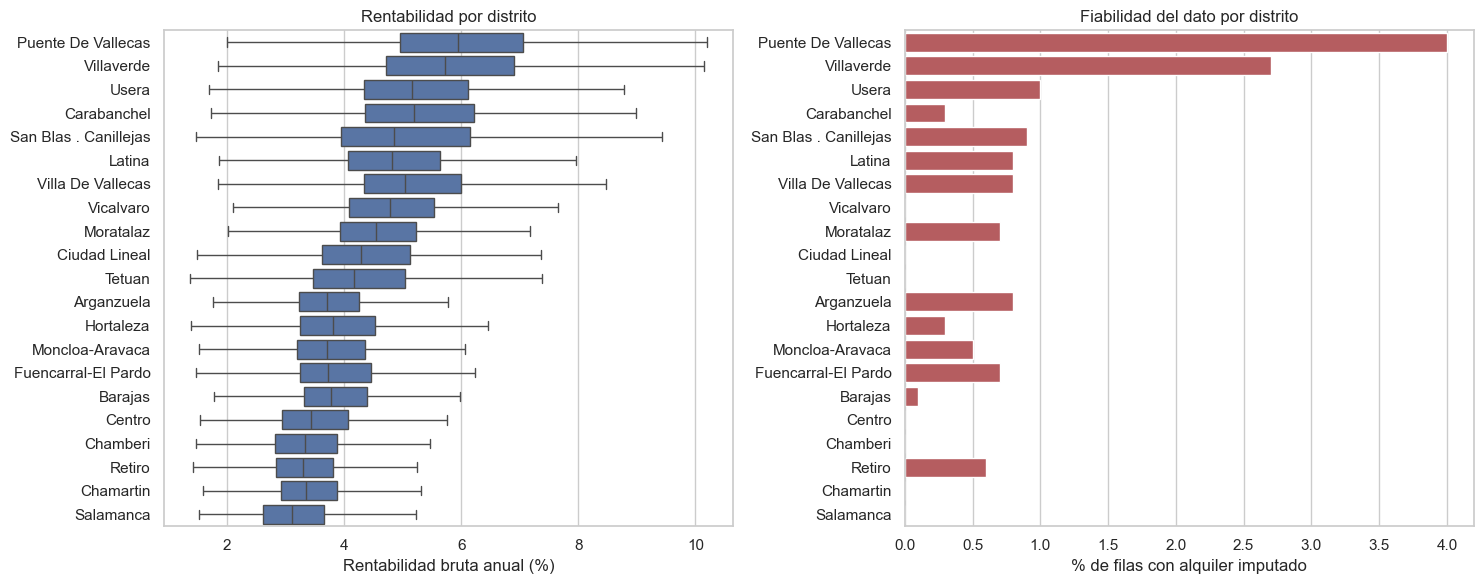

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

orden = rentabilidad_zona.index.tolist()

sns.boxplot(
    data=datos, y="distrito", x="rentabilidad_pct",
    order=orden, showfliers=False, ax=axes[0], color="#4C72B0",
)
axes[0].set(xlabel="Rentabilidad bruta anual (%)", ylabel="",
            title="Rentabilidad por distrito")

sns.barplot(
    data=rentabilidad_zona.reset_index(), y="distrito", x="pct_imputado",
    order=orden, ax=axes[1], color="#C44E52",
)
axes[1].set(xlabel="% de filas con alquiler imputado", ylabel="",
            title="Fiabilidad del dato por distrito")

plt.tight_layout()
plt.show()

2 secciones sin dato ni siquiera a nivel de distrito (excluidas del gráfico)


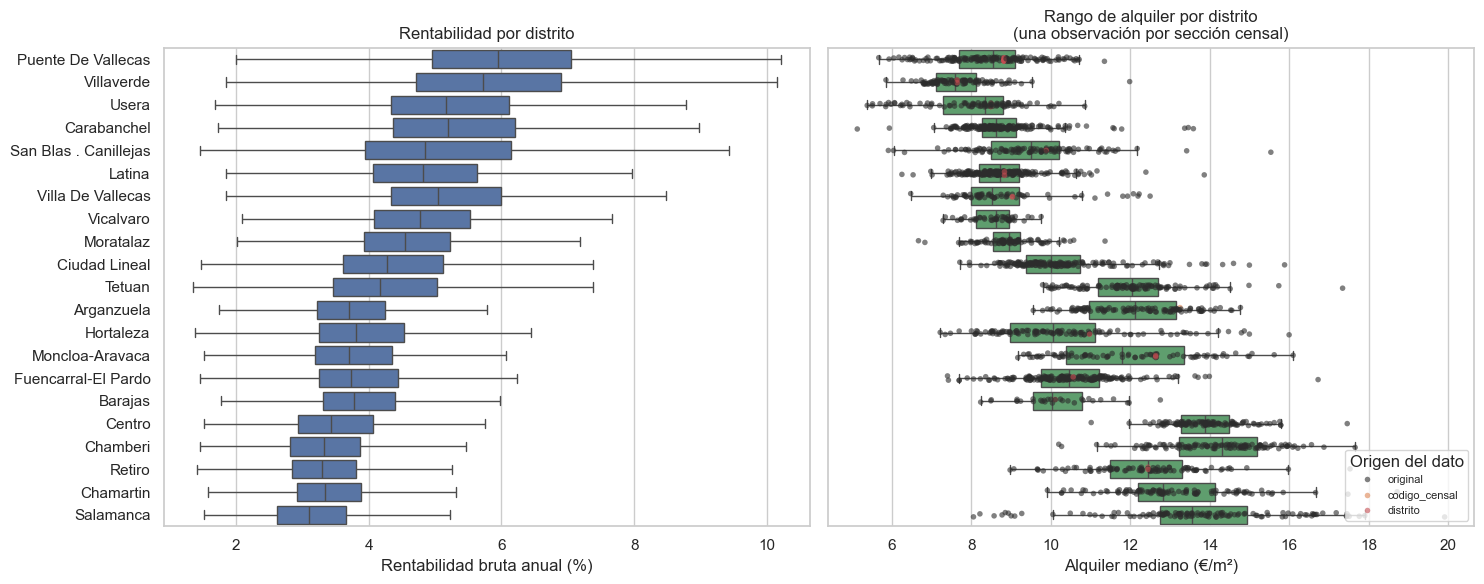

In [18]:
# Descarta las secciones sin ningun dato disponible (ni siquiera a nivel de
# distrito) -- por diseno se quedaron en NaN, y ademas su alq_nivel_imputacion
# es pd.NA, lo que rompe la comprobacion "in" contra el diccionario de paleta
secciones_unicas = datos.drop_duplicates(subset="codigo_censal")[
    ["distrito", "codigo_censal", "alq_mediana_eur_m2", "alq_nivel_imputacion"]
].dropna(subset=["alq_mediana_eur_m2"])

n_descartadas = datos.codigo_censal.nunique() - secciones_unicas.codigo_censal.nunique()
if n_descartadas:
    print(f"{n_descartadas} secciones sin dato ni siquiera a nivel de distrito "
          f"(excluidas del gráfico)")

PALETA_IMPUTACION = {
    "original": "#2c2c2c",
    "codigo_censal": "#DD8452",
    "distrito": "#C44E52",
}
paleta_presente = {
    k: v for k, v in PALETA_IMPUTACION.items()
    if k in set(secciones_unicas.alq_nivel_imputacion.dropna())
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

sns.boxplot(
    data=datos, y="distrito", x="rentabilidad_pct",
    order=orden, showfliers=False, ax=axes[0], color="#4C72B0",
)
axes[0].set(xlabel="Rentabilidad bruta anual (%)", ylabel="",
            title="Rentabilidad por distrito")

sns.boxplot(
    data=secciones_unicas, y="distrito", x="alq_mediana_eur_m2",
    order=orden, showfliers=False, ax=axes[1], color="#55A868",
)
sns.stripplot(
    data=secciones_unicas, y="distrito", x="alq_mediana_eur_m2",
    order=orden, hue="alq_nivel_imputacion", ax=axes[1],
    size=4, alpha=0.6, palette=paleta_presente,
)
axes[1].set(xlabel="Alquiler mediano (€/m²)", ylabel="",
            title="Rango de alquiler por distrito\n(una observación por sección censal)")
axes[1].legend(title="Origen del dato", loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

El panel derecho es tan importante como el izquierdo: un distrito con
rentabilidad alta y mucha imputación no es un hallazgo, es una zona sobre la
que hay poca información real. Conviene leer siempre los dos juntos.

## 9. Validación del dataset final

In [19]:
def validar(df):
    """Comprobaciones de integridad antes de exportar."""
    checks = {
        "Sin filas duplicadas":
            not df.duplicated(subset=["ASSETID", "PERIOD"]).any(),
        "PRICE positivo":
            (df.PRICE > 0).all(),
        "Superficie positiva":
            (df.CONSTRUCTEDAREA > 0).all(),
        "codigo_censal de 10 dígitos":
            df.codigo_censal.dropna().str.len().eq(10).all(),
        "codigo_censal existe en el INE":
            df.codigo_censal.dropna().isin(secciones.codigo_censal).all(),
        "Rentabilidad en rango plausible (0–15%)":
            df.rentabilidad_pct.dropna().between(0, 15).mean() > 0.95,
        "Coordenadas dentro de Madrid":
            df.geometry.to_crs(CRS_GEO).x.between(-4.0, -3.4).all(),
    }

    for nombre, ok in checks.items():
        print(f"  {'✓' if ok else '✗'}  {nombre}")

    return all(checks.values())


print(f"Dataset final: {datos.shape[0]:,} filas × {datos.shape[1]} columnas\n")
validar(datos)

Dataset final: 94,852 filas × 62 columnas

  ✗  Sin filas duplicadas
  ✓  PRICE positivo
  ✓  Superficie positiva
  ✓  codigo_censal de 10 dígitos
  ✓  codigo_censal existe en el INE
  ✓  Rentabilidad en rango plausible (0–15%)
  ✗  Coordenadas dentro de Madrid


False

In [20]:
# Resumen de cobertura por bloque de variables
bloques = {
    "Identificación": ["ASSETID", "PERIOD"],
    "Precio": ["PRICE", "UNITPRICE", "CONSTRUCTEDAREA"],
    "Geografía": ["codigo_censal", "barrio", "distrito"],
    "Catastro": ["CADCONSTRUCTIONYEAR", "CADMAXBUILDINGFLOOR", "CADDWELLINGCOUNT"],
    "Alquiler": ["alq_mediana_eur_m2", "alq_estimado_eur"],
    "Calidad": ["sec_dudosa", "alq_imputado"],
}

resumen = pd.DataFrame([
    {
        "bloque": bloque,
        "variable": col,
        "cobertura_%": round(100 * datos[col].notna().mean(), 1),
    }
    for bloque, cols in bloques.items()
    for col in cols if col in datos.columns
])

resumen

,bloque,variable,cobertura_%
0,Identificación,ASSETID,100.0
1,Identificación,PERIOD,100.0
2,Precio,PRICE,100.0
3,Precio,UNITPRICE,100.0
4,Precio,CONSTRUCTEDAREA,100.0
5,Geografía,codigo_censal,100.0
6,Geografía,barrio,99.2
7,Geografía,distrito,99.2
8,Catastro,CADCONSTRUCTIONYEAR,100.0
9,Catastro,CADMAXBUILDINGFLOOR,100.0


In [21]:
datos.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 94852 entries, 0 to 94851
Data columns (total 62 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   ASSETID                        94852 non-null  category
 1   PERIOD                         94852 non-null  Int32   
 2   PRICE                          94852 non-null  float64 
 3   UNITPRICE                      94852 non-null  float64 
 4   CONSTRUCTEDAREA                94852 non-null  Int32   
 5   ROOMNUMBER                     94852 non-null  Int32   
 6   BATHNUMBER                     94852 non-null  Int32   
 7   HASTERRACE                     94852 non-null  Int32   
 8   HASLIFT                        94852 non-null  Int32   
 9   HASAIRCONDITIONING             94852 non-null  Int32   
 10  AMENITYID                      94852 non-null  Int32   
 11  HASPARKINGSPACE                94852 non-null  Int32   
 12  ISPARKINGSPACEINCLUDEDIN

## 10. Exportación

Se guarda en Parquet: preserva los tipos (incluida la geometría) y pesa
bastante menos que un CSV.

In [22]:
SALIDA = DATA / "habitia_madrid_2018.parquet"

datos.to_parquet(SALIDA, index=False)
print(f"Guardado → {SALIDA}  ({SALIDA.stat().st_size / 1e6:.1f} MB)")

# Diccionario de datos para acompañar al dataset
diccionario = pd.DataFrame({
    "variable": datos.columns,
    "tipo": [str(t) for t in datos.dtypes],
    "n_nulos": datos.isna().sum().values,
    "cobertura_%": (100 * datos.notna().mean()).round(1).values,
})
diccionario.to_csv(DATA / "diccionario_datos.csv", index=False)
print(f"Diccionario → {DATA / 'diccionario_datos.csv'}")

Guardado → data\habitia_madrid_2018.parquet  (11.0 MB)
Diccionario → data\diccionario_datos.csv


---

## Próximos pasos

**Enriquecimiento por `codigo_censal`** — la llave ya es correcta, así que
estas fuentes se unen directamente:

| Fuente | Contenido | Nivel |
|---|---|---|
| INE — Atlas de Distribución de Renta | Renta media, mediana, Gini | Sección censal |
| INE — Censo de Población y Viviendas | Tenencia, estado del edificio, nivel educativo | Sección censal |
| Catastro INSPIRE | Antigüedad y altura del tejido edificado | Coordenadas → agregados 100 m |
| Ayuntamiento — Censo de locales | Densidad comercial y hostelera | Coordenadas → buffer |
| Ayuntamiento — Policía Municipal | Actuaciones por tipología | Distrito |

**Al pasar al modelo, tres cosas a recordar:**

1. **Excluir del set de *features*** cualquier variable que contenga `PRICE`:
   `rentabilidad_pct`, `UNITPRICE` si el target es `PRICE`.

2. **Validación cruzada espacial.** Los precios tienen autocorrelación
   espacial fuerte; un K-fold aleatorio mete pisos del mismo portal en train y
   test e infla las métricas. Usar *spatial block CV* o leave-one-barrio-out, y
   reportar ambas.

3. **Usar `sec_dudosa` y `alq_imputado`** para análisis de robustez: reentrenar
   excluyendo las filas marcadas y comprobar si las conclusiones se mantienen.

**Sobre la coherencia temporal:** todo el dataset es de 2018. Si el conjunto de
test viene de la API actual, la diferencia de métricas entre ambos mide
*concept drift*, no calidad del modelo. Conviene mantener un test interno de
2018 para separar las dos cosas.
